In [1]:
from google.colab import userdata
api_key = userdata.get('API_KEY_TRANSP')

In [6]:
import requests
import pandas as pd
import time

codigo_siafi = "20101"
dt_inicio = "01/01/2025"
dt_fim = "31/12/2025"
pagina_atual = 1
todos_os_dados = []

url = "https://api.portaldatransparencia.gov.br/api-de-dados/cartoes"

headers = {
    "accept": "*/*",
    "chave-api-dados": api_key
}

print("Iniciando coleta de dados...")

while True:
    params = {
        "codigoOrgao": codigo_siafi,
        "pagina": pagina_atual,
        "dataTransacaoInicio": dt_inicio,
        "dataTransacaoFim": dt_fim
    }

    response = requests.get(url, headers=headers, params=params)

    dados_pagina = response.json()

    if not dados_pagina:
        print(f"Fim da coleta. Total de páginas: {pagina_atual - 1}")
        break

    todos_os_dados.extend(dados_pagina)
    print(f"Página {pagina_atual} coletada... (Total acumulado: {len(todos_os_dados)})")

    pagina_atual += 1

    time.sleep(0.5)

Iniciando coleta de dados...
Página 1 coletada... (Total acumulado: 15)
Página 2 coletada... (Total acumulado: 30)
Página 3 coletada... (Total acumulado: 45)
Página 4 coletada... (Total acumulado: 60)
Página 5 coletada... (Total acumulado: 75)
Página 6 coletada... (Total acumulado: 90)
Página 7 coletada... (Total acumulado: 105)
Página 8 coletada... (Total acumulado: 120)
Página 9 coletada... (Total acumulado: 135)
Página 10 coletada... (Total acumulado: 150)
Página 11 coletada... (Total acumulado: 165)
Página 12 coletada... (Total acumulado: 180)
Página 13 coletada... (Total acumulado: 195)
Página 14 coletada... (Total acumulado: 210)
Página 15 coletada... (Total acumulado: 225)
Página 16 coletada... (Total acumulado: 240)
Página 17 coletada... (Total acumulado: 255)
Página 18 coletada... (Total acumulado: 270)
Página 19 coletada... (Total acumulado: 285)
Página 20 coletada... (Total acumulado: 300)
Página 21 coletada... (Total acumulado: 315)
Página 22 coletada... (Total acumulado: 3

In [36]:
df = pd.json_normalize(todos_os_dados)

In [37]:
df.to_csv("cartao_pgto_presidencia_2025.csv", index=False)

***Saques, estabelecimento "Não Identificado" ou "Sigiloso"***

Enquanto o id -2 é usado para operações que, por natureza, não têm um CNPJ de destino (como o saque em espécie), o -1 aparece quando:

* Gasto Sigiloso (Segurança Nacional): Na Presidência (órgão 20101), muitos gastos são protegidos por lei para não expor a rotina de segurança do Presidente ou de sua família.
* Erro de Processamento Bancário: Quando a transação vem do Banco do Brasil com algum caractere inválido ou campo corrompido.
* Transações Internacionais: quando o sistema de tratamento de dados não consegue mapear o "Tax ID" estrangeiro para o formato de CNPJ/CPF brasileiro.

In [38]:
df['valorTransacao'] = df['valorTransacao'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

In [39]:
import numpy as np

df['categoria_id'] = np.select(
    [
        df['estabelecimento.id'] == -2,
        df['estabelecimento.id'] == -1
    ],
    [
        'Saque',
        'Sigiloso'
    ],
    default='Compra Identificada'
)

In [40]:
df.head()

,id,mesExtrato,dataTransacao,valorTransacao,tipoCartao.id,tipoCartao.codigo,tipoCartao.descricao,estabelecimento.id,estabelecimento.cpfFormatado,estabelecimento.cnpjFormatado,...,unidadeGestora.orgaoVinculado.cnpj,unidadeGestora.orgaoVinculado.sigla,unidadeGestora.orgaoVinculado.nome,unidadeGestora.orgaoMaximo.codigo,unidadeGestora.orgaoMaximo.sigla,unidadeGestora.orgaoMaximo.nome,portador.cpfFormatado,portador.nis,portador.nome,categoria_id
0,538233592,02/2025,21/01/2025,100.00,1,1,Cartão de Pagamento do Governo Federal - CPGF,-2,,,...,00394411000109,PR,Presidência da República,20000,PR\t,Presidência da República,***.238.203-**,,LUCIANO BUARQUE BARBOSA,Saque
1,538233656,02/2025,22/01/2025,1000.00,1,1,Cartão de Pagamento do Governo Federal - CPGF,-2,,,...,00394411000109,PR,Presidência da República,20000,PR\t,Presidência da República,***.238.203-**,,LUCIANO BUARQUE BARBOSA,Saque
2,538233720,02/2025,22/01/2025,1000.00,1,1,Cartão de Pagamento do Governo Federal - CPGF,-2,,,...,00394411000109,PR,Presidência da República,20000,PR\t,Presidência da República,***.238.203-**,,LUCIANO BUARQUE BARBOSA,Saque
3,538233784,02/2025,24/01/2025,900.00,1,1,Cartão de Pagamento do Governo Federal - CPGF,-2,,,...,00394411000109,PR,Presidência da República,20000,PR\t,Presidência da República,***.238.203-**,,LUCIANO BUARQUE BARBOSA,Saque
4,538233848,02/2025,08/01/2025,287.96,1,1,Cartão de Pagamento do Governo Federal - CPGF,7419682,,60.570.793/0001-06,...,00394411000109,PR,Presidência da República,20000,PR\t,Presidência da República,***.383.038-**,,ROBERTO BUENO FONTANA,Compra Identificada


In [41]:
print(df.groupby('categoria_id')['valorTransacao'].agg(['sum', 'count']))

                          sum  count
categoria_id                        
Compra Identificada  80996.40    327
Saque                15300.00     17
Sigiloso             20197.03     21


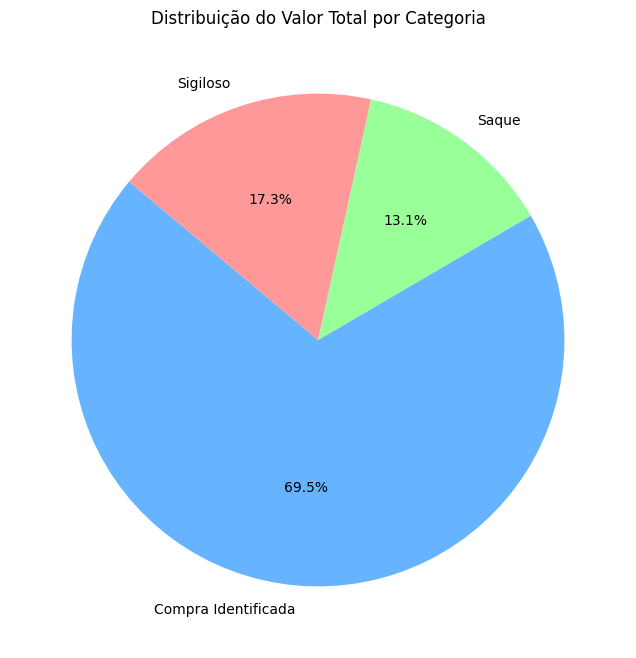

In [63]:
import matplotlib.pyplot as plt

categorias = df.groupby('categoria_id')['valorTransacao'].sum()

# 2. Gráfico de pizza
plt.figure(figsize=(8, 8))
categorias.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff','#99ff99','#ff9999'],
    title='Distribuição do Valor Total por Categoria'
)
plt.ylabel('')
plt.show()

> 30,4% dos gastos com o cartão de pagamentos não possui identificação direta de CNPJ (fornecedor)

O dado, por si só, não aponta uma ilegalidade, mas está exatamente no limite do que a lei permite.

O saque em espécie para o Suprimento de Fundos é regido pelo Decreto nº 93.872/1986, que determina que:

    O limite para saques em dinheiro é de até 30% do total de despesas de suprimento de fundos da Unidade Gestora no ano.

Saques (id -2) somaram 13,1%, abaixo do permitido.

Já os gastos sigilosos (id -1) se baseiam no Art. 24 da Lei de Acesso à Informação (Lei 12.527/2011):

    Justificativa: Segurança do Presidente, do Vice e de seus familiares.

No Portal da Transparência, o estabelecimento é ocultado para não revelar, por exemplo, em qual hotel o presidente se hospeda habitualmente ou qual empresa presta segurança privada em eventos, o que poderia gerar riscos.

O Tribunal de Contas da União (TCU) e a CGU aceitam esses 30% porque realizam controle. A norma determina que os portadores do cartão apresentem as notas fiscais aos órgãos de fiscalização em um processo interno fechado.

In [44]:
# Verificando quem mais utiliza a modalidade de Saque e Sigiloso
analise_portador = df.groupby(['portador.nome', 'categoria_id'])['valorTransacao'].sum().unstack().fillna(0)

In [47]:
# Ordenando pelos maiores saques
print(analise_portador.sort_values(by='Saque', ascending=False).head(10))

categoria_id                          Compra Identificada    Saque  Sigiloso
portador.nome                                                               
LUCIANO BUARQUE BARBOSA                            133.00  15300.0      0.00
ALEXANDRE MARINS DA SILVA CARRASCOSE                 0.00      0.0   4322.64
ALEXANDRE VAZ DE SOUZA                               0.00      0.0   7546.93
ANTONIO JOSE DE SENA BOMFIM                          0.00      0.0   7692.10
IZAIAS RODRIGUES PENHA                           13350.68      0.0    635.36
ARILSON CAVALCANTE PEREIRA                        6327.30      0.0      0.00
LEANDRO AUGUSTO ANDERSON                         10397.45      0.0      0.00
ODIMAR RAFAEL MAIA                               12742.27      0.0      0.00
ROBERTO BUENO FONTANA                            13546.84      0.0      0.00
ROGERIO DO NASCIMENTO                            24498.86      0.0      0.00


In [49]:
# Ranking de quem "movimenta" mais dinheiro
ranking_financeiro = df.groupby('portador.nome')['valorTransacao'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)

print(ranking_financeiro)

                                           sum         mean  count
portador.nome                                                     
ROGERIO DO NASCIMENTO                 24498.86   220.710450    111
LUCIANO BUARQUE BARBOSA               15433.00   857.388889     18
IZAIAS RODRIGUES PENHA                13986.04   229.279344     61
ROBERTO BUENO FONTANA                 13546.84   246.306182     55
ODIMAR RAFAEL MAIA                    12742.27   254.845400     50
LEANDRO AUGUSTO ANDERSON              10397.45   221.222340     47
ANTONIO JOSE DE SENA BOMFIM            7692.10  1098.871429      7
ALEXANDRE VAZ DE SOUZA                 7546.93  1078.132857      7
ARILSON CAVALCANTE PEREIRA             6327.30  1265.460000      5
ALEXANDRE MARINS DA SILVA CARRASCOSE   4322.64  1080.660000      4


In [52]:
# Filtrando o comportamento do Luciano (maiores saques)
print(df[df['portador.nome'] == 'LUCIANO BUARQUE BARBOSA']['categoria_id'].value_counts())

categoria_id
Saque                  17
Compra Identificada     1
Name: count, dtype: int64


In [54]:
# Filtrando o comportamento de quem tem os maiores gastos sigilosos:
print(df[df['portador.nome'] == 'ALEXANDRE MARINS DA SILVA CARRASCOSE']['categoria_id'].value_counts())

categoria_id
Sigiloso    4
Name: count, dtype: int64


In [55]:
print(df[df['portador.nome'] == 'ALEXANDRE VAZ DE SOUZA']['categoria_id'].value_counts())

categoria_id
Sigiloso    7
Name: count, dtype: int64


In [56]:
print(df[df['portador.nome'] == 'ANTONIO JOSE DE SENA BOMFIM']['categoria_id'].value_counts())

categoria_id
Sigiloso    7
Name: count, dtype: int64


In [57]:
print(df[df['portador.nome'] == 'IZAIAS RODRIGUES PENHA']['categoria_id'].value_counts())

categoria_id
Compra Identificada    58
Sigiloso                3
Name: count, dtype: int64


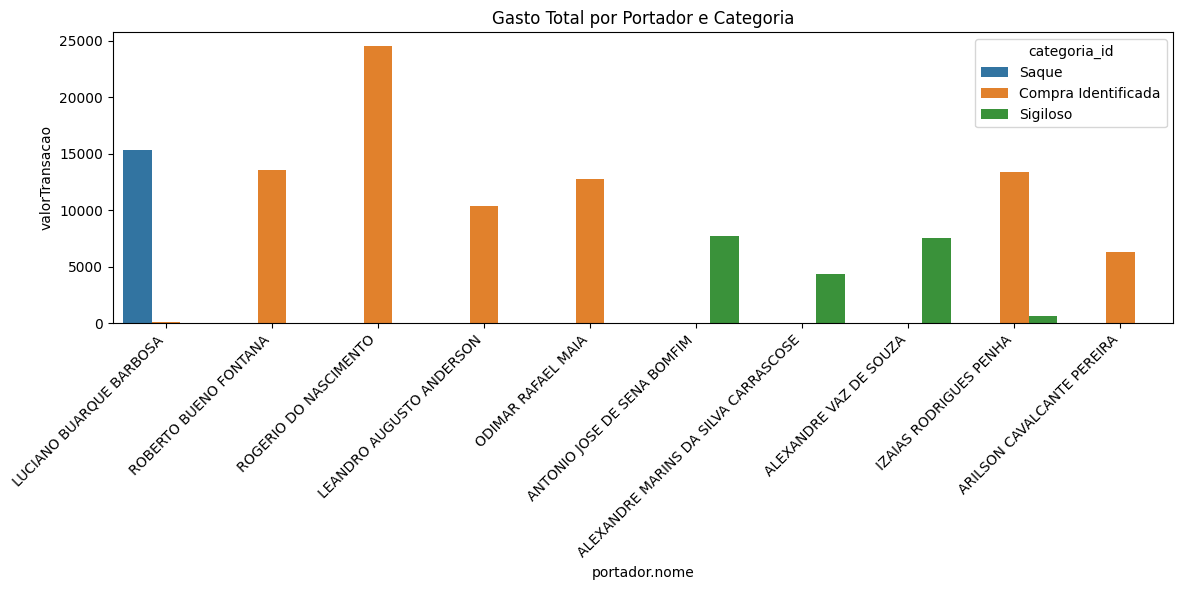

In [58]:
# Gráfico com Gasto Total por Portador e Categoria:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=df, x='portador.nome', y='valorTransacao', hue='categoria_id', estimator=sum, errorbar=None)
plt.xticks(rotation=45, ha='right')
plt.title('Gasto Total por Portador e Categoria')
plt.tight_layout()
plt.show()

In [60]:
# Entre os gastos identificados, dados dos maiores fornecedores:

compras_rastreaveis = df[df['categoria_id'] == 'Compra Identificada']

top_estabelecimentos = (
    compras_rastreaveis.groupby('estabelecimento.nome')['valorTransacao']
    .agg(['sum', 'count'])
    .sort_values(by='sum', ascending=False)
    .head(10)
)

print("--- TOP 10 ESTABELECIMENTOS (MAIORES VALORES RECEBIDOS) ---")
print(top_estabelecimentos)

--- TOP 10 ESTABELECIMENTOS (MAIORES VALORES RECEBIDOS) ---
                                                         sum  count
estabelecimento.nome                                               
AUTO POSTO PARQUE VILLA LOBOS LTDA.                 22814.58    105
AUTO POSTO HYGIENOPOLIS LTDA                        13546.84     55
AUTO POSTO GRANA LTDA                                7891.36     29
SERVICO SOCIAL DA INDUSTRIA DEPARTAMENTO REGION...   2767.90      1
POSTO DE GASOLINA E INCORPORACOES ARPOADOR LTDA      2457.79     11
REDE DE POSTOS AUTO POSTO CENTER LTDA                2283.37     10
PLAZA BRASILIA HOTEIS E TURISMO LTDA.                1782.55      2
CDG COMBUSTIVEIS LTDA                                1696.37      8
CHRYSTIANO FRANCA TEIXEIRA                           1469.85      1
POSTO DE SERVICOS PORTAL DE CAMPOS LTDA              1404.84      5


Os maiores gastos foram com combustíveis. Dos 10 estabelecimentos, 8 são postos de gasolina.

Os dois primeiros postos (Villa Lobos e Hygienopolis) somam quase R$ 36.000,00 em 160 transações. Isso indica uma concentração geográfica muito forte. Provavelmente, é onde a frota oficial que atende a Presidência em deslocamentos nessa região se abastece rotineiramente.


O Caso do SESI (Serviço Social da Indústria) foi provavelmente relacionado a algum evento.


A Pessoa Física: Chrystiano Franca Teixeira.Talvez serviço técnico, como conserto de emergência ou um reembolso.

In [64]:
# Verificando os estabelecimentos favoritos do portador que mais gasta
gastos_rogerio = df[df['portador.nome'] == 'ROGERIO DO NASCIMENTO']

top_postos_rogerio = (
    gastos_rogerio.groupby('estabelecimento.nome')['valorTransacao']
    .agg(['sum', 'count'])
    .sort_values(by='sum', ascending=False)
)

print("--- Onde o Rogério gasta o dinheiro? ---")
print(top_postos_rogerio.head(5))

--- Onde o Rogério gasta o dinheiro? ---
                                          sum  count
estabelecimento.nome                                
AUTO POSTO PARQUE VILLA LOBOS LTDA.  22814.58    105
AUTO POSTO CENTRAL PARK LTDA           838.47      3
GDO PARTICIPACOES S/A                  622.01      2
SAO GUALTER - AUTO POSTO LTDA          223.80      1


Ao todo, 95% dos gastos do maior consumidor (Rogério) está direcionado ao posto Parqui Villa Lobos. No setor público, isso pode indicar um "acordo de faturamento" ou simplesmente uma conveniência logística extrema (o posto fica no caminho da garagem ou da base de apoio).

Ticket Médio: 22.814,58/105 = **R$ 217,28** por abastecimento. Para 2025, isso é compatível com um tanque cheio de um carro de passeio ou SUV médio.

<Axes: title={'center': 'Gastos Totais por Semana em 2025'}, xlabel='data_dt'>

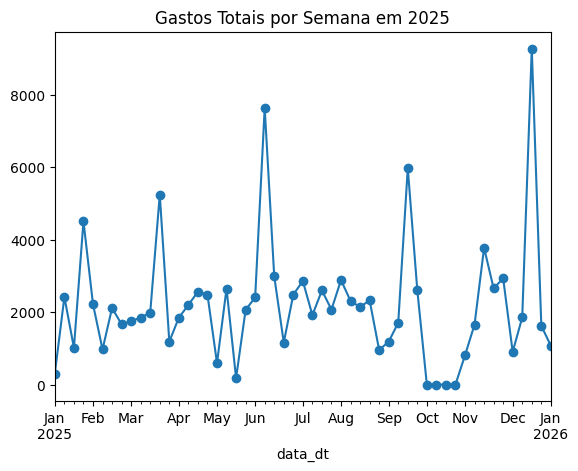

In [61]:
# Convertendo para datetime (padrão brasileiro dia/mes/ano)
df['data_dt'] = pd.to_datetime(df['dataTransacao'], dayfirst=True)

# Agrupando por semana e somando
gastos_semanais = df.resample('W', on='data_dt')['valorTransacao'].sum()

# Plotando
gastos_semanais.plot(kind='line', marker='o', title='Gastos Totais por Semana em 2025')

In [65]:
# Convertendo para datetime (dayfirst=True para o padrão brasileiro DD/MM/AAAA)
df['dt_transacao'] = pd.to_datetime(df['dataTransacao'], dayfirst=True)

# Extraindo o nome do dia da semana
df['dia_semana_nome'] = df['dt_transacao'].dt.day_name()

# Criando a flag booleana: (Sábado=5, Domingo=6)
df['is_weekend'] = df['dt_transacao'].dt.dayofweek.isin([5, 6])

In [66]:
# Filtrando apenas os gastos de Sábado e Domingo
gastos_fds = df[df['is_weekend']]

print(f"Total gasto em fins de semana: R$ {gastos_fds['valorTransacao'].sum():,.2f}")
print(f"Número de transações no FDS: {len(gastos_fds)}")

# Quais são os estabelecimentos favoritos do fim de semana?
print("\nTop estabelecimentos no FDS:")
print(gastos_fds.groupby('estabelecimento.nome')['valorTransacao'].sum().sort_values(ascending=False).head(5))

Total gasto em fins de semana: R$ 16,367.38
Número de transações no FDS: 64

Top estabelecimentos no FDS:
estabelecimento.nome
AUTO POSTO PARQUE VILLA LOBOS LTDA.                3492.25
AUTO POSTO HYGIENOPOLIS LTDA                       2617.86
SEM INFORMACAO                                     2174.34
AUTO POSTO GRANA LTDA                              1393.31
POSTO DE GASOLINA E INCORPORACOES ARPOADOR LTDA     657.71
Name: valorTransacao, dtype: float64


/tmp/ipykernel_322/2236992699.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='is_weekend', y='valorTransacao', estimator=sum, errorbar=None, palette='viridis')


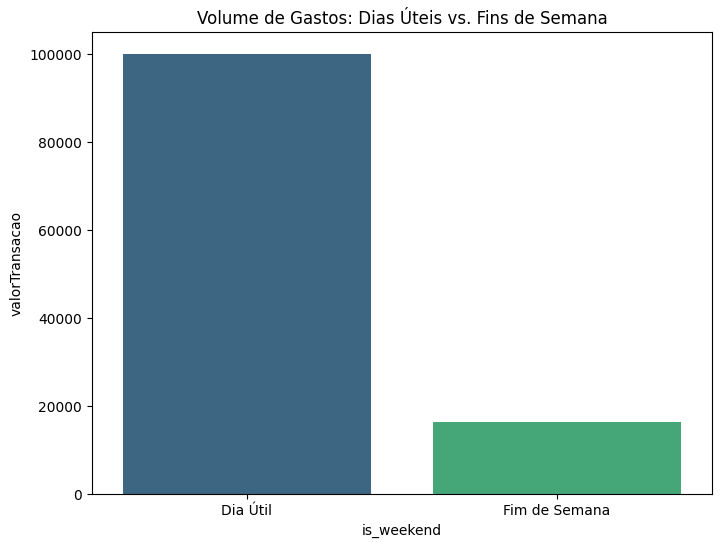

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='is_weekend', y='valorTransacao', estimator=sum, errorbar=None, palette='viridis')
plt.xticks([0, 1], ['Dia Útil', 'Fim de Semana'])
plt.title('Volume de Gastos: Dias Úteis vs. Fins de Semana')
plt.show()

Os picos de gasto em SP coincidem com as quintas e sextas-feiras, que provavelmente antecedem as agendas de fim de semana do Presidente em sua residência particular ou em eventos no estado.

In [68]:
# Criando um arquivo Excel com múltiplas abas para análise
with pd.ExcelWriter('analise_cartao_corporativo_pre_2025.xlsx') as writer:
    df.groupby('categoria_id')['valorTransacao'].sum().to_excel(writer, sheet_name='Resumo_Geral')
    top_estabelecimentos.to_excel(writer, sheet_name='Top_Fornecedores')
    ranking_financeiro.to_excel(writer, sheet_name='Ranking_Portadores')
    gastos_fds.to_excel(writer, sheet_name='Gastos_Fim_De_Semana')

print("Relatório finalizado")

Relatório finalizado
